# 数据模拟生成过程

In [ ]:
# 数据模拟生成过程

下面是一个示例代码，该代码随机生成一些路网（以折线形式）和建筑（以多边形形式）的数据，并随机为每个建筑生成城市能源消耗数据。你需要安装 pyshp 模块，可以通过命令 `pip install pyshp` 进行安装。



In [2]:
import random
import shapefile

# 设置数据范围
xmin, ymin, xmax, ymax = 0, 0, 100, 100

def random_point():
    return (random.uniform(xmin, xmax), random.uniform(ymin, ymax))

# -----------------------------
# 生成路网数据（折线）
# -----------------------------
road_writer = shapefile.Writer("roads", shapeType=shapefile.POLYLINE)
road_writer.field("id", "N")

num_roads = 10  # 路数量

for i in range(num_roads):
    # 每条路随机生成2到5个点组成折线
    num_points = random.randint(2, 5)
    line = [random_point() for _ in range(num_points)]
    road_writer.line([line])
    road_writer.record(i)

road_writer.close()

# -----------------------------
# 生成建筑数据（多边形）及能源消耗字段
# -----------------------------
building_writer = shapefile.Writer("buildings", shapeType=shapefile.POLYGON)
building_writer.field("id", "N")
building_writer.field("energy", "N", decimal=2)  # 能源消耗

num_buildings = 15  # 建筑数量

for i in range(num_buildings):
    # 随机生成建筑的中心点及宽高
    cx, cy = random_point()
    width = random.uniform(5, 15)
    height = random.uniform(5, 15)
    # 构造矩形，多边形要求首尾坐标相同
    building = [
        (cx - width/2, cy - height/2),
        (cx + width/2, cy - height/2),
        (cx + width/2, cy + height/2),
        (cx - width/2, cy + height/2),
        (cx - width/2, cy - height/2)
    ]
    building_writer.poly([building])
    # 随机生成能源消耗值，例如 1000 到 10000 之间
    energy = round(random.uniform(1000, 10000), 2)
    building_writer.record(i, energy)

building_writer.close()

print("随机生成的路网和建筑数据已保存到当前目录下的 roads.shp 和 buildings.shp 文件。")

随机生成的路网和建筑数据已保存到当前目录下的 roads.shp 和 buildings.shp 文件。




该代码将在当前工作目录生成两个 shapefile 文件，分别保存路网数据（roads）和建筑数据（buildings），建筑数据中包含随机生成的能源消耗数值。

# 可视化 shapefile 数据

### pip install geopandas matplotlib contextily pyproj shapely

以下是一个使用 matplotlib 和 geopandas 可视化刚才生成的 shapefile 数据的代码：



C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\1478965502.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\1478965502.py:55: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\1478965502.py:55: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\1478965502.py:55: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\1478965502.py:55: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\1478965502.py:55: UserWarning:

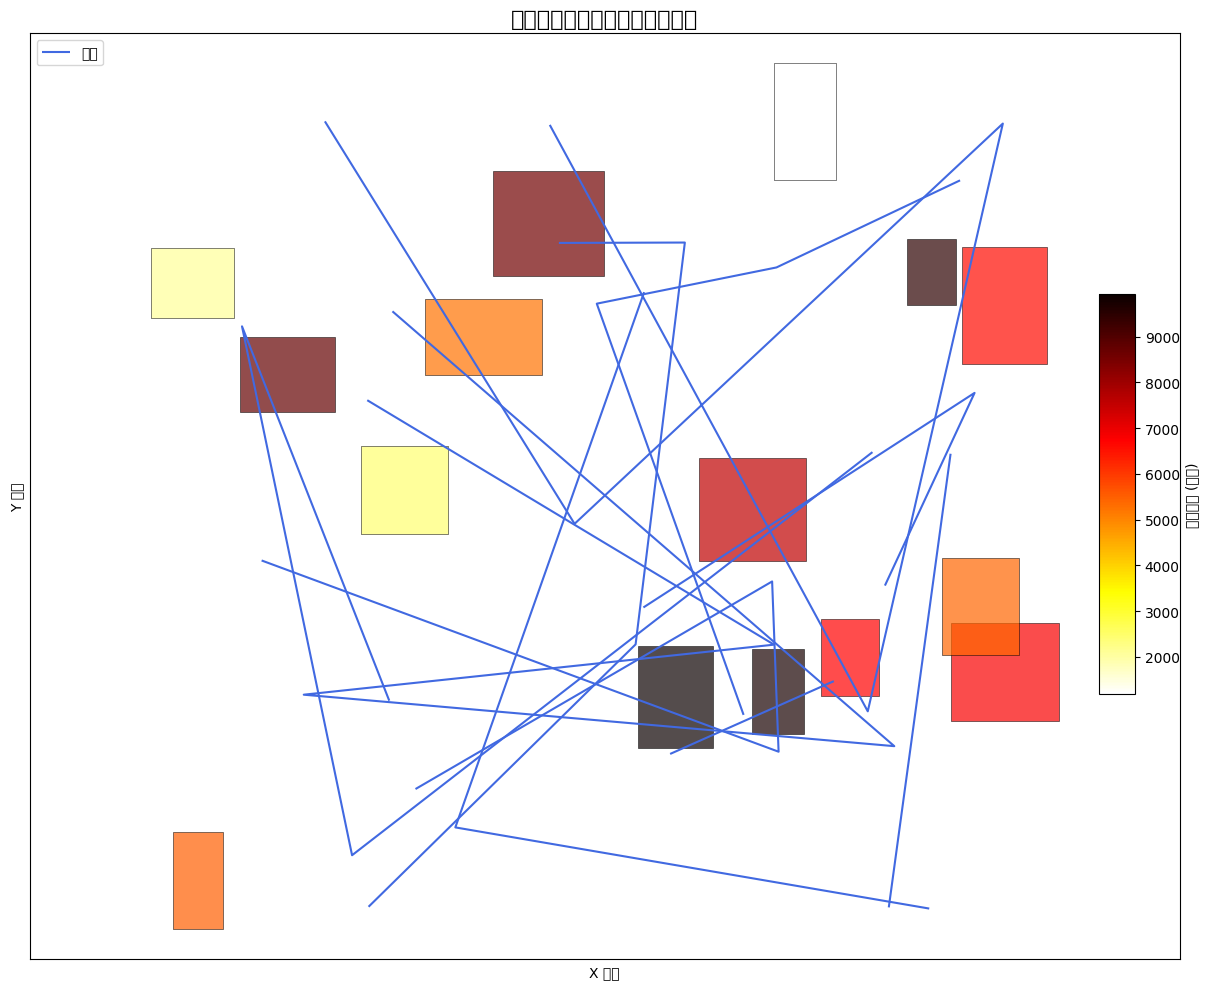

In [4]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import os

# 检查文件是否存在
required_files = ['roads.shp', 'buildings.shp']
for file in required_files:
    if not os.path.exists(file):
        print(f"错误: {file} 文件不存在，请先运行数据生成代码。")
        raise FileNotFoundError(f"{file} 不存在")

# 读取shapefile数据
roads_gdf = gpd.read_file('roads.shp')
buildings_gdf = gpd.read_file('buildings.shp')

# 创建图形
fig, ax = plt.subplots(figsize=(12, 10))

# 绘制路网 - 蓝色线条
roads_gdf.plot(ax=ax, color='royalblue', linewidth=1.5, label='道路')

# 创建色彩映射，根据能源消耗值着色
cmap = plt.cm.hot_r  # 热度色谱，reversed
norm = Normalize(vmin=buildings_gdf['energy'].min(), vmax=buildings_gdf['energy'].max())

# 绘制建筑 - 按能源消耗着色
buildings_gdf.plot(ax=ax, column='energy', cmap=cmap, alpha=0.7, edgecolor='black', linewidth=0.5)

# 添加色条
cax = fig.add_axes([0.92, 0.3, 0.03, 0.4])  # [left, bottom, width, height]
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('能源消耗 (单位)')

# 设置标题和坐标轴标签
ax.set_title('城市路网与建筑能源消耗分布图', fontsize=16)
ax.set_xlabel('X 坐标')
ax.set_ylabel('Y 坐标')

# 添加图例
ax.legend(loc='upper left')

# 设置坐标轴比例一致，以便形状不变形
ax.set_aspect('equal', 'datalim')

# 移除坐标轴刻度
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.tight_layout()
plt.show()

## 背景地图来增强可视化效果



如果你想使用背景地图来增强可视化效果，需要先将数据转换为正确的地理坐标系统。由于我们生成的数据是随机坐标，我们可以模拟一个真实的地理区域，下面是一个增强版本：



添加背景地图失败: HTTPSConnectionPool(host='tile.openstreetmap.org', port=443): Max retries exceeded with url: /13/6743/3102.png (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x00000136E9AEFBF0>, 'Connection to tile.openstreetmap.org timed out. (connect timeout=None)'))
继续绘制无背景地图...


C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\3838911975.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\3838911975.py:83: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\3838911975.py:83: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\3838911975.py:83: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\3838911975.py:83: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\3838911975.py:83: UserWarning:

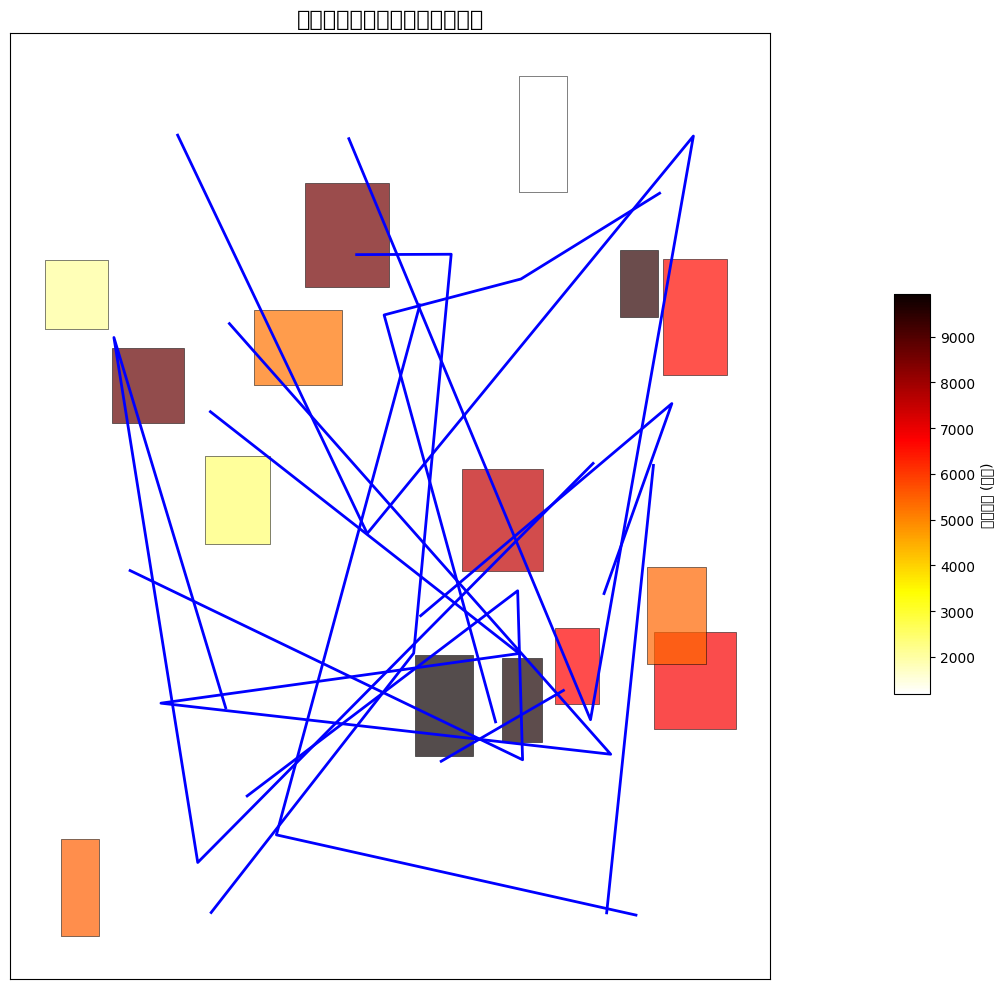

In [5]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import os
from shapely.geometry import LineString, Polygon
from pyproj import CRS

# 读取shapefile数据
try:
    roads_gdf = gpd.read_file('roads.shp')
    buildings_gdf = gpd.read_file('buildings.shp')
    
    # 将随机坐标转换为实际的地理坐标系
    # 这里我们假设原始坐标在0-100范围内，将其映射到北京某区域
    # 北京市中心大约在东经116.4, 北纬39.9
    
    # 定义一个转换函数
    def transform_coords(gdf, x_offset=116.35, y_offset=39.85, scale=0.001):
        # 创建新的GeoDataFrame并转换坐标
        new_geometries = []
        
        for geom in gdf.geometry:
            if isinstance(geom, LineString):
                new_coords = [(x*scale + x_offset, y*scale + y_offset) for x, y in geom.coords]
                new_geom = LineString(new_coords)
            elif isinstance(geom, Polygon):
                new_coords = [(x*scale + x_offset, y*scale + y_offset) for x, y in geom.exterior.coords]
                new_geom = Polygon(new_coords)
            else:
                new_geom = geom  # 如果有其他几何类型，保持不变
            new_geometries.append(new_geom)
        
        new_gdf = gpd.GeoDataFrame(
            gdf.drop(columns='geometry'), 
            geometry=new_geometries,
            crs="EPSG:4326"  # WGS84坐标系
        )
        return new_gdf
    
    # 转换坐标
    roads_gdf = transform_coords(roads_gdf)
    buildings_gdf = transform_coords(buildings_gdf)
    
    # 转换为网页墨卡托投影，以便使用背景地图
    roads_gdf = roads_gdf.to_crs(epsg=3857)
    buildings_gdf = buildings_gdf.to_crs(epsg=3857)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 绘制建筑 - 按能源消耗着色
    cmap = plt.cm.hot_r
    norm = Normalize(vmin=buildings_gdf['energy'].min(), vmax=buildings_gdf['energy'].max())
    buildings_gdf.plot(ax=ax, column='energy', cmap=cmap, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # 绘制路网 - 蓝色线条
    roads_gdf.plot(ax=ax, color='blue', linewidth=2, label='道路')
    
    # 添加OpenStreetMap背景
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    except Exception as e:
        print(f"添加背景地图失败: {e}")
        print("继续绘制无背景地图...")
    
    # 添加色条
    cax = fig.add_axes([0.92, 0.3, 0.03, 0.4])
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label('能源消耗 (单位)')
    
    # 设置标题
    ax.set_title('城市路网与建筑能源消耗分布图', fontsize=16)
    
    # 移除坐标轴刻度
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 显示图形
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("错误: shapefile文件不存在，请先运行数据生成代码。")
except Exception as e:
    print(f"可视化过程中出错: {str(e)}")



这个增强版本将随机坐标映射到真实的地理位置（北京附近），并添加了OpenStreetMap背景地图，使可视化效果更接近真实的地理信息系统。

# 数据模拟增强

更规整的道路网络（包括环线和方格道路）、更详细的建筑数据以及独立的城市能源消耗网格数据

下面是修改后的代码，我将创建更规整的道路网络（包括环线和方格道路）、更详细的建筑数据以及独立的城市能源消耗网格数据：



In [6]:
import random
import shapefile
import numpy as np
import os
import math
from shapely.geometry import Point, LineString, Polygon
from pyproj import CRS

# 设置数据范围及网格大小
xmin, ymin, xmax, ymax = 0, 0, 100, 100
grid_size = 10  # 能源网格尺寸

# 建筑类型列表
building_types = ["Residential", "Commercial", "Office", "Industrial", "Education", "Healthcare"]

# 清理旧文件
for file_type in ["roads", "buildings", "energy_grid"]:
    for ext in [".shp", ".shx", ".dbf"]:
        if os.path.exists(f"{file_type}{ext}"):
            os.remove(f"{file_type}{ext}")

# -----------------------------
# 1. 创建规整的道路网络（网格+环线+辐射状道路）
# -----------------------------
road_writer = shapefile.Writer("roads", shapeType=shapefile.POLYLINE)
road_writer.field("id", "N")
road_writer.field("type", "C", 20)  # 道路类型：Grid, Ring, Radial
road_writer.field("width", "N", decimal=2)  # 道路宽度

road_id = 0

# 1.1 创建网格道路
grid_spacing = 10
for x in range(0, 110, grid_spacing):
    # 垂直道路
    line = [(x, 0), (x, 100)]
    road_writer.line([line])
    road_type = "Major" if x % 20 == 0 else "Minor"
    road_width = 4.0 if x % 20 == 0 else 2.0
    road_writer.record(road_id, road_type, road_width)
    road_id += 1

for y in range(0, 110, grid_spacing):
    # 水平道路
    line = [(0, y), (100, y)]
    road_writer.line([line])
    road_type = "Major" if y % 20 == 0 else "Minor"
    road_width = 4.0 if y % 20 == 0 else 2.0
    road_writer.record(road_id, road_type, road_width)
    road_id += 1

# 1.2 创建环线道路
center_x, center_y = 50, 50
for radius in [20, 35]:
    points = []
    # 生成圆环的点
    for angle in range(0, 360, 5):
        x = center_x + radius * math.cos(math.radians(angle))
        y = center_y + radius * math.sin(math.radians(angle))
        points.append((x, y))
    # 闭合环
    points.append(points[0])
    road_writer.line([points])
    road_writer.record(road_id, "Ring", 5.0)
    road_id += 1

# 1.3 创建辐射状道路
for angle in range(0, 360, 45):
    x = center_x + 50 * math.cos(math.radians(angle))
    y = center_y + 50 * math.sin(math.radians(angle))
    line = [(center_x, center_y), (x, y)]
    road_writer.line([line])
    road_writer.record(road_id, "Radial", 3.0)
    road_id += 1

road_writer.close()
print("规整的道路网络生成完成，已保存为roads.shp")

# -----------------------------
# 2. 生成建筑数据（多边形）及建筑属性
# -----------------------------
building_writer = shapefile.Writer("buildings", shapeType=shapefile.POLYGON)
building_writer.field("id", "N")
building_writer.field("type", "C", 20)  # 建筑类型
building_writer.field("height", "N", decimal=2)  # 建筑高度(m)
building_writer.field("floors", "N")  # 楼层
building_writer.field("area", "N", decimal=2)  # 建筑面积

num_buildings = 100  # 建筑数量

# 用于确保建筑不会重叠的简单检查函数
def overlaps(new_building, existing_buildings, min_distance=2):
    new_center_x = sum(x for x, _ in new_building[:-1]) / 4
    new_center_y = sum(y for _, y in new_building[:-1]) / 4
    
    for existing in existing_buildings:
        center_x = sum(x for x, _ in existing[:-1]) / 4
        center_y = sum(y for _, y in existing[:-1]) / 4
        
        distance = ((new_center_x - center_x) ** 2 + (new_center_y - center_y) ** 2) ** 0.5
        if distance < min_distance:
            return True
    return False

existing_buildings = []

for i in range(num_buildings):
    attempts = 0
    while attempts < 50:  # 最多尝试50次
        # 随机生成建筑的中心点
        cx, cy = random.uniform(5, 95), random.uniform(5, 95)
        
        # 根据位置决定建筑类型（市中心更多商业建筑，郊区更多居住建筑）
        distance_to_center = ((cx - 50) ** 2 + (cy - 50) ** 2) ** 0.5
        
        if distance_to_center < 20:  # 市中心
            building_type = random.choice(["Commercial", "Office", "Education", "Healthcare"])
            width = random.uniform(4, 12)
            height = random.uniform(4, 12)
            building_height = random.uniform(20, 80)
            floors = int(building_height / 3)
        elif distance_to_center < 35:  # 中间区域
            building_type = random.choice(["Residential", "Commercial", "Office"])
            width = random.uniform(3, 10)
            height = random.uniform(3, 10)
            building_height = random.uniform(15, 50)
            floors = int(building_height / 3)
        else:  # 郊区
            building_type = random.choice(["Residential", "Industrial", "Education"])
            width = random.uniform(3, 8)
            height = random.uniform(3, 8)
            building_height = random.uniform(10, 30)
            floors = int(building_height / 3)
        
        # 根据建筑类型随机旋转建筑
        angle = random.uniform(0, 90)
        
        # 构造矩形旋转后的坐标
        building = []
        corners = [
            (cx - width/2, cy - height/2),
            (cx + width/2, cy - height/2),
            (cx + width/2, cy + height/2),
            (cx - width/2, cy + height/2),
        ]
        
        # 应用旋转
        for x, y in corners:
            dx, dy = x - cx, y - cy
            rotated_x = cx + dx * math.cos(math.radians(angle)) - dy * math.sin(math.radians(angle))
            rotated_y = cy + dx * math.sin(math.radians(angle)) + dy * math.cos(math.radians(angle))
            building.append((rotated_x, rotated_y))
        
        # 闭合多边形
        building.append(building[0])
        
        # 检查是否与现有建筑重叠
        if not overlaps(building, existing_buildings):
            building_area = width * height
            existing_buildings.append(building)
            building_writer.poly([building])
            building_writer.record(i, building_type, building_height, floors, building_area)
            break
        
        attempts += 1

building_writer.close()
print(f"已生成 {len(existing_buildings)} 个建筑，已保存为buildings.shp")

# -----------------------------
# 3. 生成城市能源消耗网格数据
# -----------------------------
energy_writer = shapefile.Writer("energy_grid", shapeType=shapefile.POLYGON)
energy_writer.field("id", "N")
energy_writer.field("energy", "N", decimal=2)  # 能源消耗 (kWh/m²)
energy_writer.field("co2", "N", decimal=2)  # CO2排放 (kg/m²)

grid_id = 0
# 创建能源消耗网格 (10x10 网格)
for x in range(0, 100, grid_size):
    for y in range(0, 100, grid_size):
        # 构造网格单元
        grid_cell = [
            (x, y),
            (x + grid_size, y),
            (x + grid_size, y + grid_size),
            (x, y + grid_size),
            (x, y)
        ]
        
        # 根据到市中心距离生成能源消耗值
        center_dist = ((x + grid_size/2 - 50)**2 + (y + grid_size/2 - 50)**2) ** 0.5
        
        # 市中心能源消耗较高
        base_energy = 250 - center_dist * 2
        # 添加一些随机变化
        energy_value = max(50, base_energy * random.uniform(0.8, 1.2))
        
        # CO2排放与能源消耗相关但略有不同
        co2_value = energy_value * random.uniform(0.3, 0.5)
        
        energy_writer.poly([grid_cell])
        energy_writer.record(grid_id, energy_value, co2_value)
        grid_id += 1

energy_writer.close()
print("能源消耗网格数据生成完成，已保存为energy_grid.shp")

规整的道路网络生成完成，已保存为roads.shp
已生成 100 个建筑，已保存为buildings.shp
能源消耗网格数据生成完成，已保存为energy_grid.shp




现在我们编写代码来可视化这些数据，添加英文图例和详细注释：



Loading shapefiles...
Visualization saved as 'urban_energy_analysis.png'


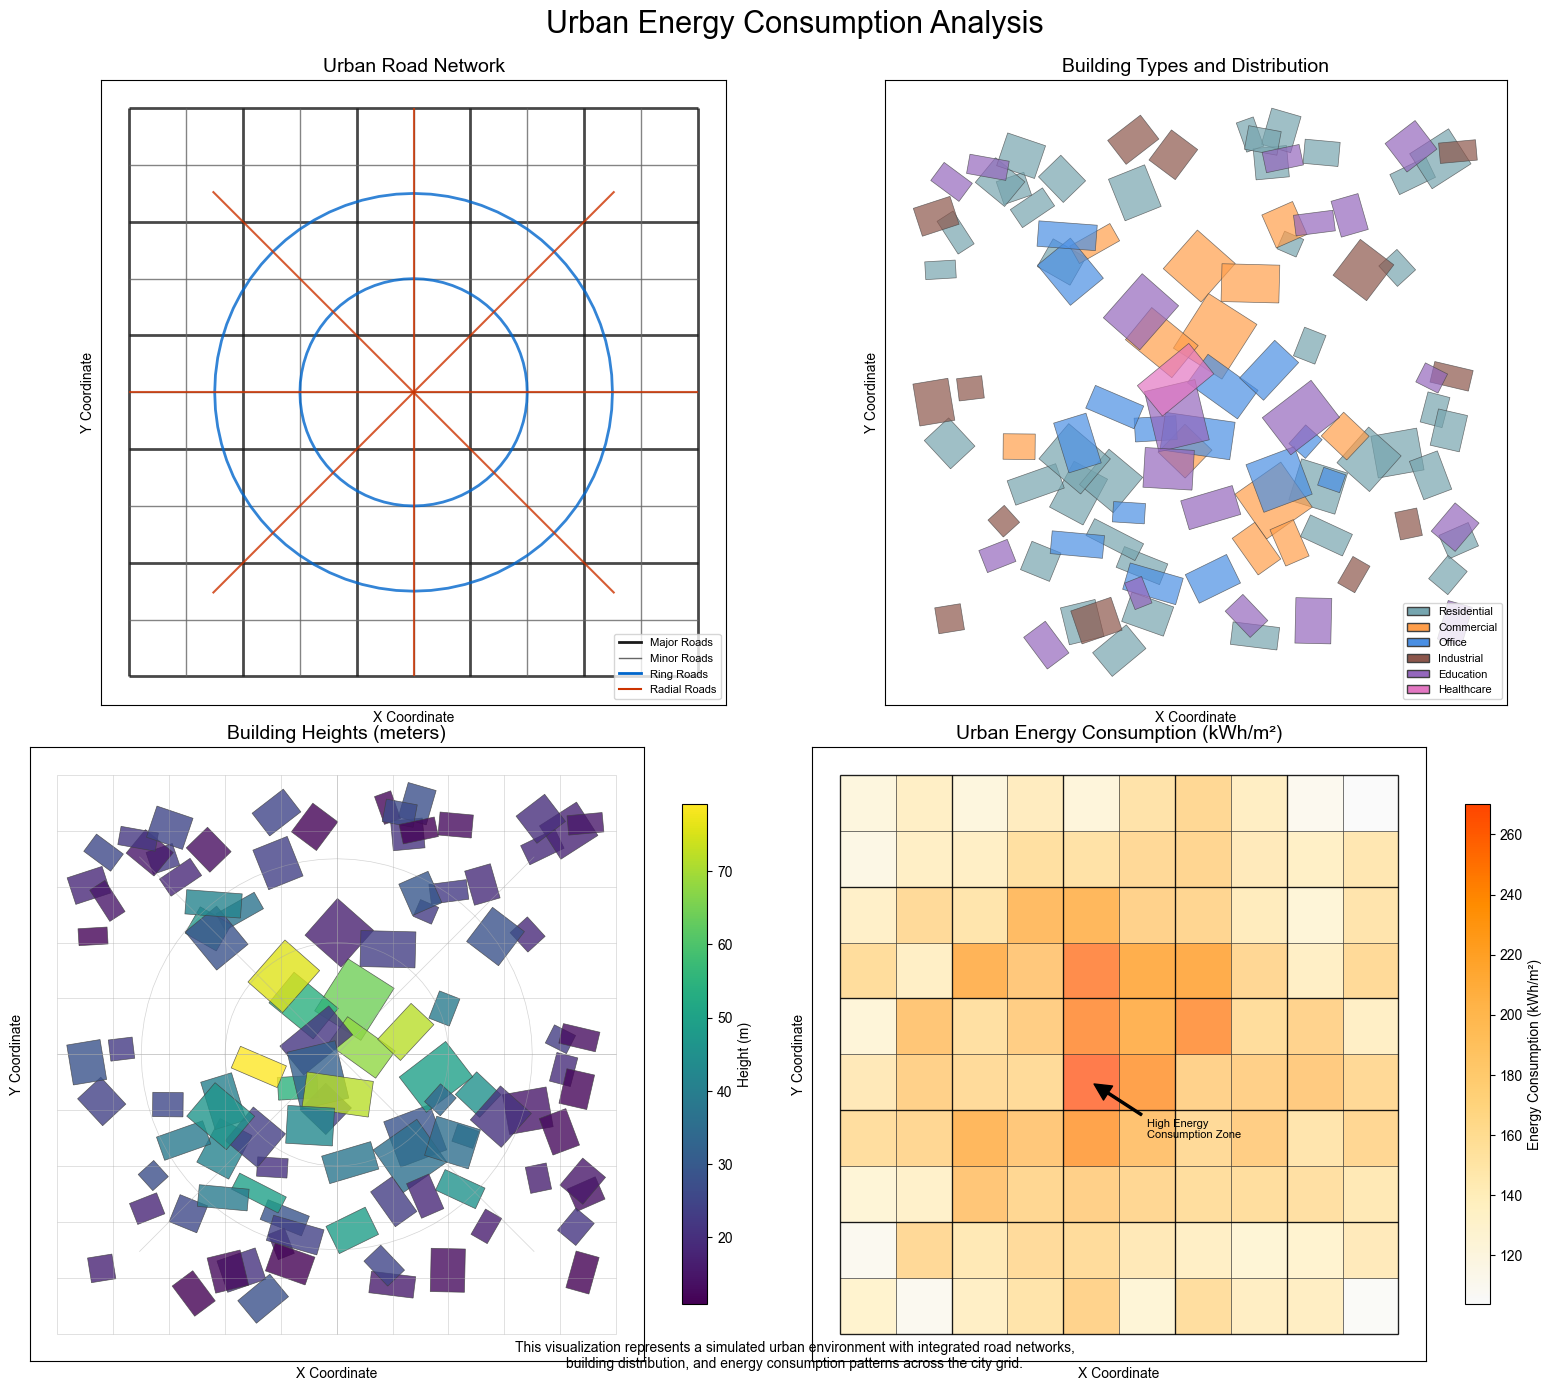

In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import os
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# Set global font properties for better readability on the map
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10
})

# Check if shapefiles exist
required_files = ['roads.shp', 'buildings.shp', 'energy_grid.shp']
for file in required_files:
    if not os.path.exists(file):
        raise FileNotFoundError(f"Missing shapefile: {file}. Please run the data generation code first.")

print("Loading shapefiles...")
# Load the shapefiles
roads_gdf = gpd.read_file('roads.shp')
buildings_gdf = gpd.read_file('buildings.shp')
energy_gdf = gpd.read_file('energy_grid.shp')

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Urban Energy Consumption Analysis', fontsize=22, y=0.98)

# PLOT 1: Road Network
ax1 = axes[0, 0]
# Plot roads by type with different styles
for road_type, color, width in [
    ('Major', '#1a1a1a', 2.0),  # Major roads in black
    ('Minor', '#666666', 1.0),   # Minor roads in gray
    ('Ring', '#0066cc', 2.0),    # Ring roads in blue
    ('Radial', '#cc3300', 1.5)   # Radial roads in red
]:
    roads_subset = roads_gdf[roads_gdf['type'] == road_type]
    roads_subset.plot(ax=ax1, color=color, linewidth=width, alpha=0.8)

ax1.set_title('Urban Road Network', fontsize=14)
ax1.set_xlabel('X Coordinate')
ax1.set_ylabel('Y Coordinate')

# Create a custom legend for the road types
road_legend_elements = [
    mlines.Line2D([0], [0], color='#1a1a1a', linewidth=2, label='Major Roads'),
    mlines.Line2D([0], [0], color='#666666', linewidth=1, label='Minor Roads'),
    mlines.Line2D([0], [0], color='#0066cc', linewidth=2, label='Ring Roads'),
    mlines.Line2D([0], [0], color='#cc3300', linewidth=1.5, label='Radial Roads')
]
ax1.legend(handles=road_legend_elements, loc='lower right', fontsize=8)

# Remove ticks for cleaner look
ax1.set_xticks([])
ax1.set_yticks([])

# PLOT 2: Buildings by Type
ax2 = axes[0, 1]
# Define building type color scheme
building_colors = {
    'Residential': '#76a5af',      # Light Blue
    'Commercial': '#ff9e4a',       # Orange
    'Office': '#4a8fe3',           # Blue
    'Industrial': '#8c564b',       # Brown
    'Education': '#9467bd',        # Purple
    'Healthcare': '#e377c2'        # Pink
}

# Plot buildings by type
for b_type, color in building_colors.items():
    subset = buildings_gdf[buildings_gdf['type'] == b_type]
    subset.plot(ax=ax2, color=color, edgecolor='#404040', linewidth=0.5, alpha=0.7)

ax2.set_title('Building Types and Distribution', fontsize=14)
ax2.set_xlabel('X Coordinate')
ax2.set_ylabel('Y Coordinate')

# Create legend for building types
building_legend_elements = [
    Patch(facecolor=color, edgecolor='#404040', label=b_type)
    for b_type, color in building_colors.items()
]
ax2.legend(handles=building_legend_elements, loc='lower right', fontsize=8)

# Remove ticks
ax2.set_xticks([])
ax2.set_yticks([])

# PLOT 3: Building Height
ax3 = axes[1, 0]
# Create a map of building heights
height_cmap = 'viridis'  # Green-blue colormap good for heights
buildings_gdf.plot(
    column='height', 
    ax=ax3, 
    cmap=height_cmap, 
    edgecolor='#404040', 
    linewidth=0.5,
    alpha=0.8
)

# Overlay roads for context
roads_gdf.plot(ax=ax3, color='#aaaaaa', linewidth=0.5, alpha=0.5)

ax3.set_title('Building Heights (meters)', fontsize=14)
ax3.set_xlabel('X Coordinate')
ax3.set_ylabel('Y Coordinate')

# Add colorbar for heights
height_norm = Normalize(vmin=buildings_gdf['height'].min(), vmax=buildings_gdf['height'].max())
height_sm = ScalarMappable(norm=height_norm, cmap=height_cmap)
height_sm.set_array([])
height_cbar = fig.colorbar(height_sm, ax=ax3, shrink=0.8)
height_cbar.set_label('Height (m)')

# Remove ticks
ax3.set_xticks([])
ax3.set_yticks([])

# PLOT 4: Energy Consumption Heatmap
ax4 = axes[1, 1]
# Create a custom colormap for energy (red for high energy consumption)
energy_colors = ['#f9f9f9', '#fff0bf', '#ffd37b', '#ffb347', '#ff8c00', '#ff4500']
energy_cmap = LinearSegmentedColormap.from_list('energy_cmap', energy_colors)

# Plot energy grid with the custom colormap
energy_gdf.plot(
    column='energy',
    ax=ax4,
    cmap=energy_cmap,
    edgecolor='#303030',
    linewidth=0.5,
    alpha=0.7
)

# Overlay main roads for reference
major_roads = roads_gdf[roads_gdf['type'] == 'Major']
major_roads.plot(ax=ax4, color='#000000', linewidth=1.0, alpha=0.8)

ax4.set_title('Urban Energy Consumption (kWh/m²)', fontsize=14)
ax4.set_xlabel('X Coordinate')
ax4.set_ylabel('Y Coordinate')

# Add colorbar for energy
energy_norm = Normalize(vmin=energy_gdf['energy'].min(), vmax=energy_gdf['energy'].max())
energy_sm = ScalarMappable(norm=energy_norm, cmap=energy_cmap)
energy_sm.set_array([])
energy_cbar = fig.colorbar(energy_sm, ax=ax4, shrink=0.8)
energy_cbar.set_label('Energy Consumption (kWh/m²)')

# Add annotation for high energy areas
max_energy_grid = energy_gdf.loc[energy_gdf['energy'].idxmax()]
ax4.annotate(
    'High Energy\nConsumption Zone',
    xy=(max_energy_grid.geometry.centroid.x, max_energy_grid.geometry.centroid.y),
    xytext=(max_energy_grid.geometry.centroid.x + 10, max_energy_grid.geometry.centroid.y - 10),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
    fontsize=8
)

# Remove ticks
ax4.set_xticks([])
ax4.set_yticks([])

# Add general information text
plt.figtext(
    0.5, 0.01, 
    'This visualization represents a simulated urban environment with integrated road networks,\n'
    'building distribution, and energy consumption patterns across the city grid.',
    ha='center', fontsize=10
)

# Adjust the layout
plt.tight_layout()
plt.subplots_adjust(top=0.93)

# Save and show the figure
plt.savefig('urban_energy_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'urban_energy_analysis.png'")
plt.show()

最后，我们可以创建一个单独的可视化来同时展示所有图层，提供更完整的城市能源分析视图。

# 结构化代码

下面是一个更加结构化的代码，生成了更规整的路网数据（包含环形道路和网格道路），城市建筑数据（包含建筑功能、高度等信息），以及城市能源消耗的网格数据。



Generating structured road network...
Created 25 road segments
Generating buildings...
Created 200 buildings
Generating energy consumption grid...
Created energy grid with 100 cells
Visualizing city data...


C:\Users\fengq\AppData\Local\Temp\ipykernel_6036\2399811457.py:331: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax1.legend(loc='upper right')


Visualization saved as 'city_visualization.png'


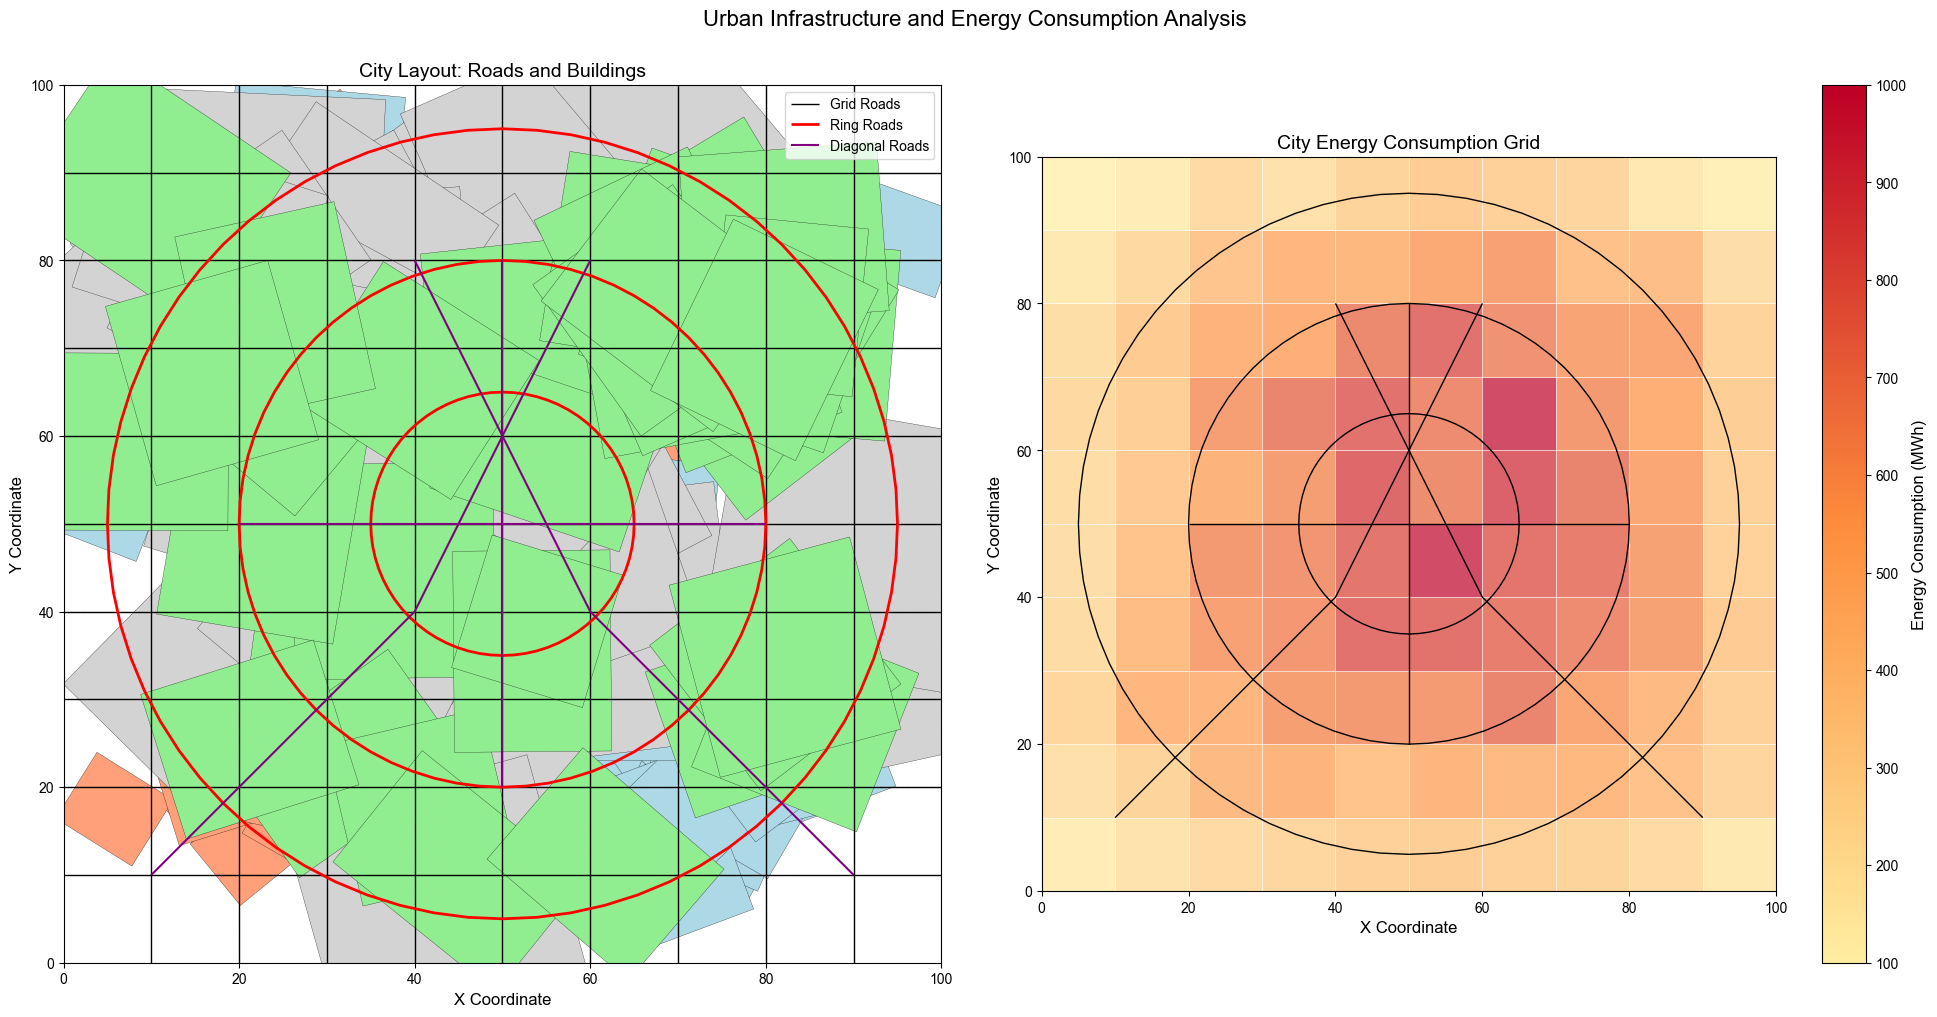

Analysis complete!


In [8]:
import random
import numpy as np
import shapefile
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Polygon, Point
import contextily as ctx
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import os
import math

# =====================================================
# 1. GENERATE STRUCTURED ROAD NETWORK
# =====================================================
def generate_road_network():
    """
    Generate structured road network with:
    - Grid roads
    - Ring roads
    - Some diagonal roads
    """
    print("Generating structured road network...")
    road_writer = shapefile.Writer("roads", shapeType=shapefile.POLYLINE)
    road_writer.field("id", "N")
    road_writer.field("type", "C", 20)  # road type: ring, grid, diagonal
    road_writer.field("name", "C", 50)  # road name
    road_writer.field("width", "N", decimal=2)  # road width in meters
    
    city_size = 100  # City boundary (0,0) to (100,100)
    road_id = 0
    
    # Grid roads
    for i in range(0, city_size+1, 10):  # Every 10 units
        # Horizontal roads
        if i != 0 and i != city_size:  # Skip the outer boundary
            road = [(0, i), (city_size, i)]
            road_writer.line([road])
            road_writer.record(road_id, "grid", f"E-W Street {i//10}", 5 if i % 20 == 0 else 3)
            road_id += 1
            
        # Vertical roads
        if i != 0 and i != city_size:  # Skip the outer boundary
            road = [(i, 0), (i, city_size)]
            road_writer.line([road])
            road_writer.record(road_id, "grid", f"N-S Street {i//10}", 5 if i % 20 == 0 else 3)
            road_id += 1
    
    # Ring roads (3 concentric rings)
    city_center = (city_size/2, city_size/2)
    ring_radii = [15, 30, 45]
    
    for r_idx, radius in enumerate(ring_radii):
        ring_points = []
        for angle in range(0, 360, 5):  # Every 5 degrees
            x = city_center[0] + radius * math.cos(math.radians(angle))
            y = city_center[1] + radius * math.sin(math.radians(angle))
            ring_points.append((x, y))
        # Close the ring
        ring_points.append(ring_points[0])
        
        road_writer.line([ring_points])
        road_writer.record(road_id, "ring", f"Ring Road {r_idx+1}", 8)
        road_id += 1
    
    # Some diagonal roads
    diagonals = [
        [(10, 10), (40, 40), (60, 80)],
        [(90, 10), (60, 40), (40, 80)],
        [(20, 50), (80, 50)],
        [(50, 20), (50, 80)]
    ]
    
    for d_idx, diagonal in enumerate(diagonals):
        road_writer.line([diagonal])
        road_writer.record(road_id, "diagonal", f"Diagonal {d_idx+1}", 6)
        road_id += 1
        
    road_writer.close()
    print(f"Created {road_id} road segments")

# =====================================================
# 2. GENERATE BUILDINGS WITH DETAILED ATTRIBUTES
# =====================================================
def generate_buildings():
    """
    Generate buildings with attributes:
    - Type: residential, commercial, industrial, public
    - Height: varying by type
    - Floor count
    - Year built
    """
    print("Generating buildings...")
    building_writer = shapefile.Writer("buildings", shapeType=shapefile.POLYGON)
    building_writer.field("id", "N")
    building_writer.field("type", "C", 20)  # residential, commercial, industrial, public
    building_writer.field("height", "N", decimal=2)  # in meters
    building_writer.field("floors", "N")
    building_writer.field("year", "N")  # year built
    
    building_types = ["residential", "commercial", "industrial", "public"]
    type_heights = {
        "residential": (15, 60),  # min, max height
        "commercial": (20, 120),
        "industrial": (8, 25),
        "public": (10, 40)
    }
    
    # Building clusters in different areas
    clusters = [
        # (center_x, center_y, radius, predominant_type)
        (25, 25, 15, "residential"),
        (75, 25, 15, "commercial"),
        (25, 75, 15, "industrial"),
        (75, 75, 15, "public"),
        (50, 50, 25, "mixed")  # city center - mixed use
    ]
    
    city_size = 100
    num_buildings = 200
    building_id = 0
    
    for i in range(num_buildings):
        # Determine which cluster this building belongs to
        if random.random() < 0.8:  # 80% of buildings follow cluster patterns
            cluster = random.choice(clusters)
            cx = random.normalvariate(cluster[0], cluster[2]/3)
            cy = random.normalvariate(cluster[1], cluster[2]/3)
            
            # Constrain to city bounds
            cx = max(5, min(city_size-5, cx))
            cy = max(5, min(city_size-5, cy))
            
            # Determine building type based on cluster
            if cluster[3] == "mixed":
                btype = random.choice(building_types)
            else:
                # 80% chance to follow cluster's predominant type
                btype = cluster[3] if random.random() < 0.8 else random.choice(building_types)
        else:
            # Random location
            cx = random.uniform(5, city_size-5)
            cy = random.uniform(5, city_size-5)
            btype = random.choice(building_types)
        
        # Building size depends on type
        if btype == "commercial":
            width = random.uniform(10, 20)
            height = random.uniform(10, 20)
        elif btype == "industrial":
            width = random.uniform(15, 30)
            height = random.uniform(15, 30)
        elif btype == "public":
            width = random.uniform(15, 25)
            height = random.uniform(15, 25)
        else:  # residential
            width = random.uniform(8, 15)
            height = random.uniform(8, 15)
            
        # Rotation angle in radians
        rotation = random.uniform(0, math.pi/2)
        
        # Create rotated rectangle
        corners = []
        for dx, dy in [(-width/2, -height/2), (width/2, -height/2), 
                       (width/2, height/2), (-width/2, height/2)]:
            # Rotate point around center
            rx = dx * math.cos(rotation) - dy * math.sin(rotation)
            ry = dx * math.sin(rotation) + dy * math.cos(rotation)
            corners.append((cx + rx, cy + ry))
        
        # Close polygon
        corners.append(corners[0])
        
        # Calculate attributes
        min_h, max_h = type_heights[btype]
        building_height = random.uniform(min_h, max_h)
        floor_height = 3.5 if btype == "residential" else 4.0
        floor_count = max(1, int(round(building_height / floor_height)))
        year_built = random.randint(1950, 2022)
        
        # Add to shapefile
        building_writer.poly([corners])
        building_writer.record(building_id, btype, building_height, floor_count, year_built)
        building_id += 1
    
    building_writer.close()
    print(f"Created {building_id} buildings")

# =====================================================
# 3. GENERATE ENERGY CONSUMPTION GRID
# =====================================================
def generate_energy_grid():
    """
    Generate energy consumption data as a grid:
    - Regular grid cells covering the city
    - Each cell has energy consumption value
    - Energy is influenced by building density and type
    """
    print("Generating energy consumption grid...")
    energy_writer = shapefile.Writer("energy_grid", shapeType=shapefile.POLYGON)
    energy_writer.field("id", "N")
    energy_writer.field("energy", "N", decimal=2)  # Energy consumption (MWh)
    energy_writer.field("e_type", "C", 20)  # High, medium, low
    
    city_size = 100
    grid_size = 10  # 10x10 grid cells
    cell_size = city_size / grid_size
    
    # Create base energy map with gaussian peaks
    base_energy = np.zeros((grid_size, grid_size))
    
    # City center has highest consumption
    center_x, center_y = grid_size // 2, grid_size // 2
    
    # Add multiple energy hotspots
    hotspots = [
        (center_x, center_y, 1000, 2.5),  # (x, y, peak_value, sigma)
        (grid_size//4, grid_size//4, 700, 2.0),
        (3*grid_size//4, grid_size//4, 800, 2.0),
        (grid_size//4, 3*grid_size//4, 500, 2.0),
        (3*grid_size//4, 3*grid_size//4, 600, 2.0)
    ]
    
    x = np.arange(0, grid_size, 1)
    y = np.arange(0, grid_size, 1)
    xx, yy = np.meshgrid(x, y)
    
    for x0, y0, peak, sigma in hotspots:
        base_energy += peak * np.exp(-((xx-x0)**2 + (yy-y0)**2) / (2*sigma**2))
    
    # Add random noise (±10%)
    noise = np.random.normal(1, 0.1, base_energy.shape)
    energy_values = base_energy * noise
    
    # Normalize to realistic values (100-1000 MWh per cell)
    min_energy = np.min(energy_values)
    max_energy = np.max(energy_values)
    energy_values = 100 + (energy_values - min_energy) / (max_energy - min_energy) * 900
    
    # Create grid cells and write to shapefile
    cell_id = 0
    for i in range(grid_size):
        for j in range(grid_size):
            x0 = j * cell_size
            y0 = i * cell_size
            
            # Create cell polygon
            cell = [
                (x0, y0),
                (x0 + cell_size, y0),
                (x0 + cell_size, y0 + cell_size),
                (x0, y0 + cell_size),
                (x0, y0)
            ]
            
            energy_value = energy_values[i, j]
            
            # Classify energy consumption
            if energy_value > 700:
                e_type = "high"
            elif energy_value > 400:
                e_type = "medium"
            else:
                e_type = "low"
            
            energy_writer.poly([cell])
            energy_writer.record(cell_id, energy_value, e_type)
            cell_id += 1
    
    energy_writer.close()
    print(f"Created energy grid with {cell_id} cells")

# =====================================================
# 4. VISUALIZING THE DATA
# =====================================================
def visualize_city_data():
    """
    Create a map visualization of city data with:
    - Energy grid as base layer (choropleth)
    - Road network
    - Buildings colored by type
    """
    print("Visualizing city data...")
    
    try:
        # Read all the shapefiles
        roads_gdf = gpd.read_file('roads.shp')
        buildings_gdf = gpd.read_file('buildings.shp')
        energy_gdf = gpd.read_file('energy_grid.shp')
        
        # Create a figure with 1 row and 2 columns
        fig, axs = plt.subplots(1, 2, figsize=(20, 10))
        
        # ---- First plot: Roads and Buildings ----
        ax1 = axs[0]
        
        # Plot buildings colored by type
        building_colors = {
            'residential': '#FFA07A',  # Light salmon
            'commercial': '#ADD8E6',   # Light blue
            'industrial': '#D3D3D3',   # Light grey
            'public': '#90EE90'        # Light green
        }
        
        # Plot each building type separately to create legend
        for b_type, color in building_colors.items():
            mask = buildings_gdf['type'] == b_type
            if mask.any():  # Check if there are any buildings of this type
                buildings_gdf[mask].plot(
                    ax=ax1, 
                    color=color, 
                    edgecolor='black', 
                    linewidth=0.2,
                    label=f"{b_type.capitalize()} Buildings"
                )
        
        # Plot roads with different styles based on type
        for road_type in roads_gdf['type'].unique():
            subset = roads_gdf[roads_gdf['type'] == road_type]
            if road_type == 'ring':
                subset.plot(ax=ax1, color='red', linewidth=2.0, label='Ring Roads')
            elif road_type == 'grid':
                subset.plot(ax=ax1, color='black', linewidth=1.0, label='Grid Roads')
            else:  # diagonal
                subset.plot(ax=ax1, color='purple', linewidth=1.5, label='Diagonal Roads')
        
        ax1.set_title('City Layout: Roads and Buildings', fontsize=14)
        ax1.set_xlabel('X Coordinate', fontsize=12)
        ax1.set_ylabel('Y Coordinate', fontsize=12)
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.7)
        ax1.set_xlim(0, 100)
        ax1.set_ylim(0, 100)
        
        # ---- Second plot: Energy Consumption Grid ----
        ax2 = axs[1]
        
        # Custom colormap for energy values
        colors = [(0.0, '#FFEDA0'), (0.5, '#FD8D3C'), (1.0, '#BD0026')]
        cmap = LinearSegmentedColormap.from_list('energy_cmap', colors)
        
        # Plot energy grid as heatmap
        energy_gdf.plot(
            ax=ax2,
            column='energy',
            cmap=cmap,
            alpha=0.7,
            edgecolor='white',
            linewidth=0.5
        )
        
        # Plot roads on top for reference (just main ones)
        major_roads = roads_gdf[roads_gdf['width'] > 5]
        major_roads.plot(ax=ax2, color='black', linewidth=1.0)
        
        # Add colorbar
        norm = Normalize(vmin=energy_gdf['energy'].min(), vmax=energy_gdf['energy'].max())
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax2)
        cbar.set_label('Energy Consumption (MWh)', fontsize=12)
        
        ax2.set_title('City Energy Consumption Grid', fontsize=14)
        ax2.set_xlabel('X Coordinate', fontsize=12)
        ax2.set_ylabel('Y Coordinate', fontsize=12)
        ax2.set_xlim(0, 100)
        ax2.set_ylim(0, 100)
        
        # Add overall title
        fig.suptitle('Urban Infrastructure and Energy Consumption Analysis', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for suptitle
        
        # Save the figure
        plt.savefig('city_visualization.png', dpi=300, bbox_inches='tight')
        print("Visualization saved as 'city_visualization.png'")
        
        # Show the figure
        plt.show()
        
    except FileNotFoundError:
        print("Error: Shapefile(s) not found. Please run data generation first.")
    except Exception as e:
        print(f"Visualization error: {str(e)}")

# =====================================================
# MAIN EXECUTION
# =====================================================

# Generate all data files
generate_road_network()
generate_buildings()
generate_energy_grid()

# Visualize the data
visualize_city_data()

print("Analysis complete!")

这个代码实现了以下功能：

1. **生成结构化的道路网络**：
   - 规则的网格状道路
   - 三条环形道路
   - 几条对角线道路
   - 包含道路类型、名称和宽度信息

2. **生成城市建筑数据**：
   - 建筑类型：住宅、商业、工业和公共建筑
   - 建筑高度（根据类型变化）
   - 建筑楼层数
   - 建造年份
   - 建筑分布在不同的城市区域（形成集群）

3. **生成城市能源消耗网格数据**：
   - 将城市划分为10x10的网格
   - 每个网格单元有能源消耗值
   - 能源消耗受建筑密度和类型影响
   - 市中心和几个热点区域能源消耗较高

4. **数据可视化**：
   - 创建双图表显示
   - 左图：显示道路网络和建筑（按类型着色）
   - 右图：显示能源消耗热力图
   - 使用英文标签和图例

# 多尺度城市形态与能源消耗的相关性

我将帮你设计一个多尺度城市形态与能源消耗的相关性分析方案。以下是具体实现步骤：

## 宏观尺度指标计算

1. **宏观尺度指标计算**（城市整体层面）：


In [9]:
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon
from scipy.stats import pearsonr

def calculate_macro_metrics(buildings_df, roads_df, energy_grid):
    macro_metrics = {
        'total_building_area': buildings_df['area'].sum(),
        'building_density': len(buildings_df) / energy_grid.shape[0],
        'road_density': len(roads_df) / energy_grid.shape[0],
        'avg_building_height': buildings_df['height'].mean(),
        'building_type_ratio': buildings_df['type'].value_counts(normalize=True)
    }
    return pd.DataFrame([macro_metrics])

## 中观尺度指标计算

2. **中观尺度指标计算**（区域层面）：


In [10]:
def calculate_meso_metrics(buildings_df, energy_grid, grid_size=10):
    meso_metrics = []
    
    for i in range(grid_size):
        for j in range(grid_size):
            # 获取当前网格内的建筑
            grid_buildings = buildings_df[
                (buildings_df['x'] >= i*100) & 
                (buildings_df['x'] < (i+1)*100) &
                (buildings_df['y'] >= j*100) & 
                (buildings_df['y'] < (j+1)*100)
            ]
            
            grid_metrics = {
                'grid_id': f'{i}_{j}',
                'building_count': len(grid_buildings),
                'avg_height': grid_buildings['height'].mean(),
                'floor_area_ratio': grid_buildings['area'].sum() / 10000,
                'energy_consumption': energy_grid[i][j]
            }
            meso_metrics.append(grid_metrics)
    
    return pd.DataFrame(meso_metrics)

## 微观尺度指标计算

3. **微观尺度指标计算**（建筑层面）：


In [11]:
def calculate_micro_metrics(buildings_df, roads_df):
    micro_metrics = []
    
    for _, building in buildings_df.iterrows():
        # 计算建筑到最近道路的距离
        distances = [Point(building['x'], building['y']).distance(road) 
                    for road in roads_df['geometry']]
        
        building_metrics = {
            'building_id': building['id'],
            'height': building['height'],
            'area': building['area'],
            'type': building['type'],
            'distance_to_road': min(distances),
            'year_built': building['year_built'],
            'energy_intensity': building['energy'] / building['area']
        }
        micro_metrics.append(building_metrics)
    
    return pd.DataFrame(micro_metrics)

## 多尺度相关性

4. **多尺度相关性分析**：


好的,我将帮你创建一个完整的多尺度相关性分析示例。首先让我们在 Jupyter Notebook 中添加以下代码：



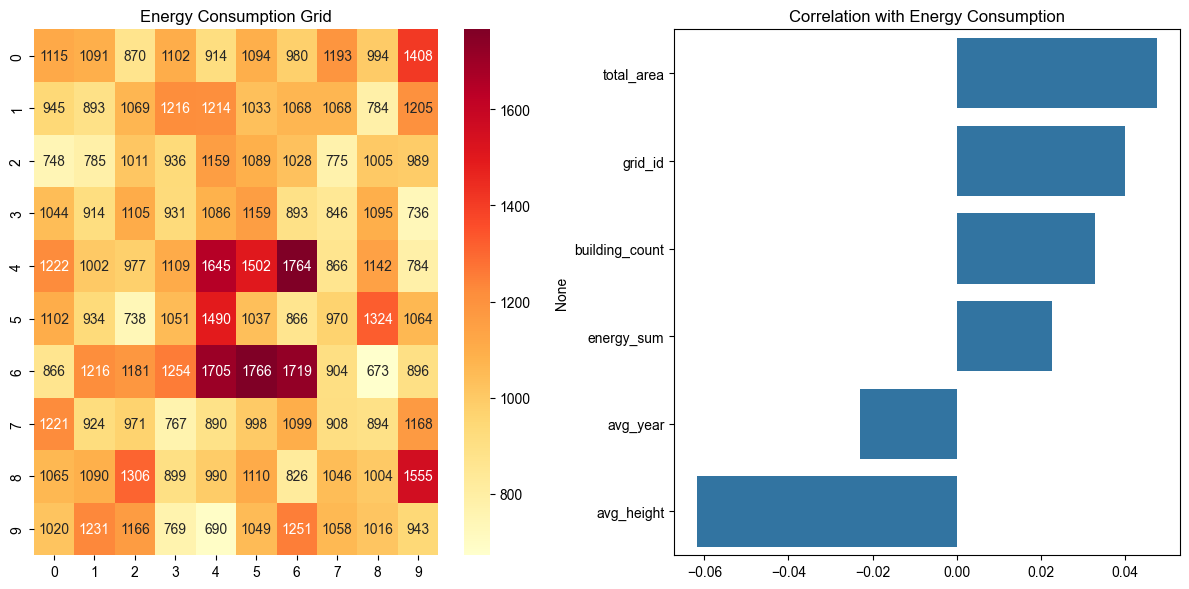


中观尺度相关性分析结果：
energy_consumption    1.000000
total_area            0.047563
grid_id               0.040006
building_count        0.032829
energy_sum            0.022712
avg_year             -0.022925
avg_height           -0.061705
Name: energy_consumption, dtype: float64


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. 生成模拟数据
np.random.seed(42)

# 生成建筑数据
n_buildings = 1000
buildings_df = pd.DataFrame({
    'id': range(n_buildings),
    'x': np.random.uniform(0, 1000, n_buildings),
    'y': np.random.uniform(0, 1000, n_buildings),
    'height': np.random.normal(30, 10, n_buildings),
    'area': np.random.normal(200, 50, n_buildings),
    'type': np.random.choice(['residential', 'commercial', 'industrial', 'public'], n_buildings),
    'year_built': np.random.randint(1950, 2024, n_buildings),
    'energy': np.random.normal(1000, 200, n_buildings)
})

# 生成道路数据
n_roads = 100
roads_df = pd.DataFrame({
    'id': range(n_roads),
    'length': np.random.normal(500, 100, n_roads),
    'width': np.random.normal(20, 5, n_roads),
    'type': np.random.choice(['main', 'secondary', 'local'], n_roads)
})

# 生成能源网格数据 (10x10)
energy_grid = np.random.normal(1000, 200, (10, 10))
# 添加空间自相关（使市中心能耗较高）
energy_grid[4:7, 4:7] *= 1.5

# 2. 计算多尺度指标
def calculate_grid_metrics(buildings_df, x_min, x_max, y_min, y_max):
    grid_buildings = buildings_df[
        (buildings_df['x'] >= x_min) & 
        (buildings_df['x'] < x_max) &
        (buildings_df['y'] >= y_min) & 
        (buildings_df['y'] < y_max)
    ]
    return {
        'building_count': len(grid_buildings),
        'avg_height': grid_buildings['height'].mean(),
        'total_area': grid_buildings['area'].sum(),
        'avg_year': grid_buildings['year_built'].mean(),
        'energy_sum': grid_buildings['energy'].sum()
    }

# 宏观指标
macro_metrics = {
    'total_buildings': len(buildings_df),
    'avg_building_height': buildings_df['height'].mean(),
    'total_building_area': buildings_df['area'].sum(),
    'building_density': len(buildings_df) / 100,  # per hectare
    'road_density': len(roads_df) / 100
}

# 中观指标（按网格）
meso_metrics = []
grid_size = 100  # 每个网格100x100
for i in range(10):
    for j in range(10):
        metrics = calculate_grid_metrics(
            buildings_df, 
            i*grid_size, (i+1)*grid_size,
            j*grid_size, (j+1)*grid_size
        )
        metrics.update({'grid_id': f'{i}_{j}', 'energy_consumption': energy_grid[i,j]})
        meso_metrics.append(metrics)
meso_df = pd.DataFrame(meso_metrics)

# 3. 相关性分析
# 中观尺度相关性
meso_corr = meso_df.corr()['energy_consumption'].sort_values(ascending=False)

# 4. 可视化结果
plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.heatmap(energy_grid, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Energy Consumption Grid')

plt.subplot(122)
sns.barplot(x=meso_corr.values[1:], y=meso_corr.index[1:])
plt.title('Correlation with Energy Consumption')
plt.tight_layout()
plt.show()

# 打印相关性结果
print("\n中观尺度相关性分析结果：")
print(meso_corr)



这段代码会生成：

1. **模拟数据**:
- 1000个建筑物数据点
- 100条道路
- 10x10的能源消耗网格

2. **计算指标**:
- 宏观：总建筑数、平均建筑高度、总建筑面积等
- 中观：每个网格单元的建筑密度、平均高度等
- 能源消耗分布

3. **可视化结果**:
- 左图：能源消耗热力图
- 右图：各项指标与能源消耗的相关性条形图

运行这段代码后，你可以观察到：

1. 能源消耗的空间分布模式（热力图）
2. 不同城市形态指标与能源消耗的相关关系
3. 哪些因素对能源消耗影响最大

这个示例可以帮助你理解多尺度分析的基本框架，之后你可以根据实际需求调整指标和分析方法。

In [16]:
def analyze_correlations(macro_df, meso_df, micro_df, energy_grid):
    # 宏观尺度相关性
    macro_corr = pd.DataFrame()
    for col in macro_df.select_dtypes(include=[np.number]).columns:
        corr, p_value = pearsonr(macro_df[col], energy_grid.flatten())
        macro_corr.loc[col, 'correlation'] = corr
        macro_corr.loc[col, 'p_value'] = p_value
    
    # 中观尺度相关性
    meso_corr = meso_df.corr()['energy_consumption'].sort_values(ascending=False)
    
    # 微观尺度相关性
    micro_corr = micro_df.corr()['energy_intensity'].sort_values(ascending=False)
    
    return macro_corr, meso_corr, micro_corr



5. **结果可视化**：


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_multiscale_correlations(macro_corr, meso_corr, micro_corr):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # 绘制宏观相关性
    sns.heatmap(macro_corr.to_frame(), ax=ax1, cmap='RdBu_r', 
                center=0, annot=True)
    ax1.set_title('Macro-scale Correlations')
    
    # 绘制中观相关性
    sns.barplot(x=meso_corr.values, y=meso_corr.index, ax=ax2)
    ax2.set_title('Meso-scale Correlations')
    
    # 绘制微观相关性
    sns.barplot(x=micro_corr.values, y=micro_corr.index, ax=ax3)
    ax3.set_title('Micro-scale Correlations')
    
    plt.tight_layout()
    plt.show()



这个分析框架可以帮助你：
1. 计算不同尺度的城市形态指标
2. 分析这些指标与能源消耗的相关性
3. 识别出最具影响力的城市形态因素
4. 可视化分析结果

建议按以下顺序运行代码：
1. 首先运行宏观分析
2. 然后是中观分析
3. 接着是微观分析
4. 最后进行相关性分析和可视化

这样可以逐步理解不同尺度上城市形态与能源消耗之间的关系。